<a href="https://colab.research.google.com/github/Enock-Yegon/Introduction-to-Python/blob/main/day1wk4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pivoting


In [ ]:
import pandas as pd
data = {
    'Country': ['Kenya', 'Kenya', 'Uganda', 'Kenya', 'Uganda', 'Kenya'],
    'Status': ["paid", "paid", "paid", "pending", "pending", "paid"],
    'Amount': [1000, 2000, 10000, 5000, 2000,1000]
}
df = pd.DataFrame(data)
summary_table = df.pivot_table(
    index='Country',
    columns='Status',
    values='Amount',
    aggfunc='sum',
    fill_value=0
)
summary_table

Status,paid,pending
Country,,
Kenya,4000,5000
Uganda,10000,2000


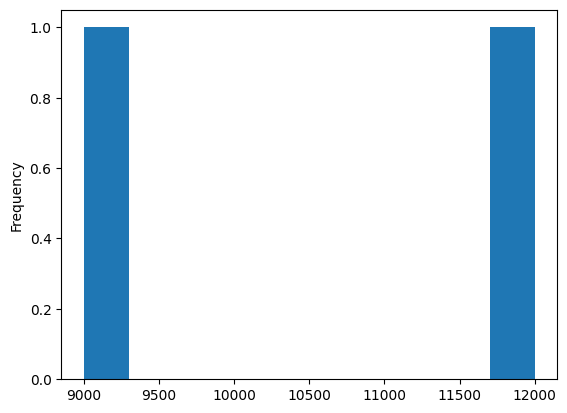

In [ ]:
import matplotlib.pyplot as plt
data = df.groupby("Country")["Amount"].sum().sort_values()
data.plot(kind="hist")

plt.show()


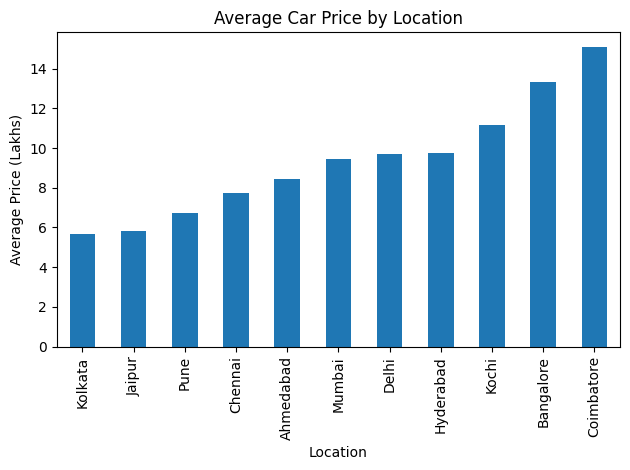

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("used_cars_data.csv")
sales = df.groupby("Location")["Price"].mean().sort_values()

# Plot simple bar chart
sales.plot(kind="bar")
plt.title("Average Car Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price (Lakhs)")
plt.tight_layout()

plt.show()

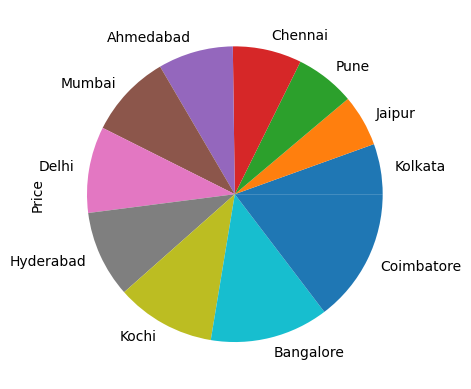

In [ ]:
sales.plot(kind="pie")
plt.show()

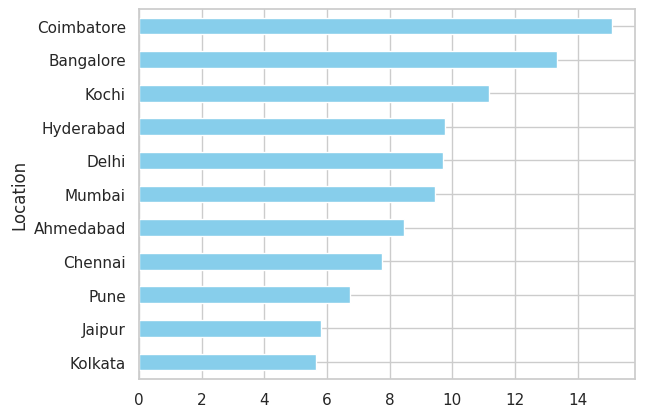

In [ ]:
sales.plot(kind="barh", color="skyblue")
plt.show()

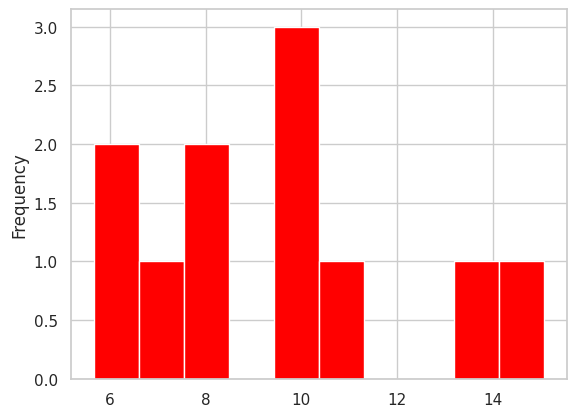

In [ ]:
sales.plot(kind="hist", color="red")
plt.show()

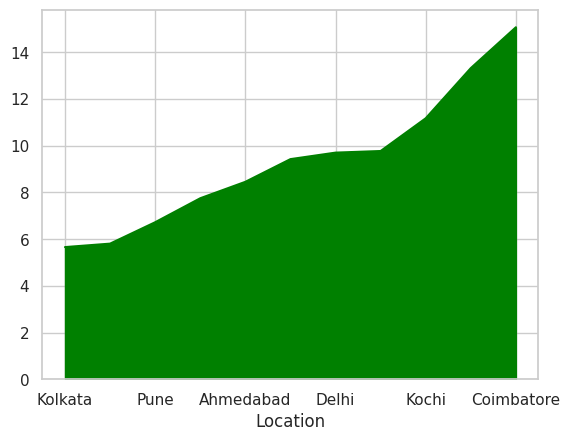

In [ ]:
sales.plot(kind="area", color="green")
plt.show()

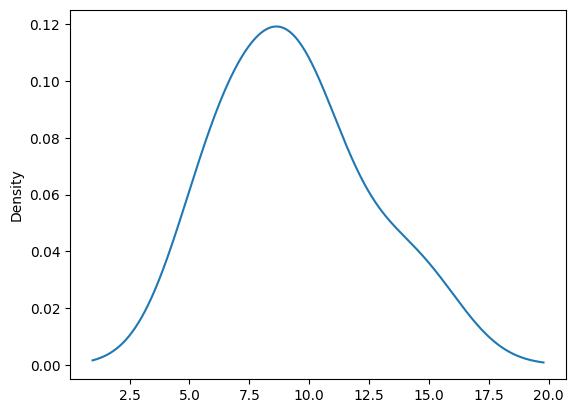

In [ ]:
sales.plot(kind="kde")
plt.show()

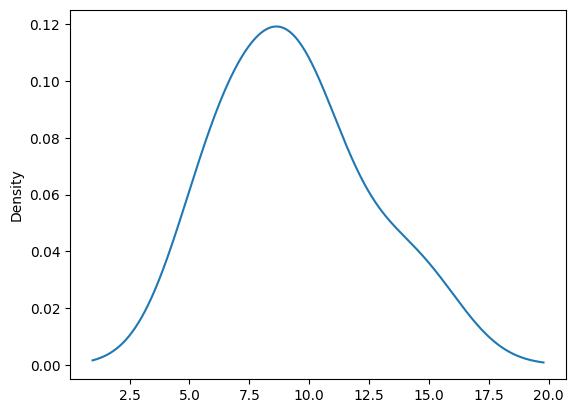

In [ ]:
sales.plot(kind="density")
plt.show()

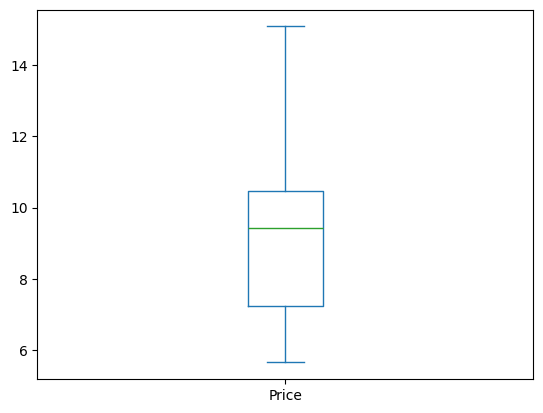

In [ ]:
sales.plot(kind="box")
plt.show()

/tmp/ipykernel_764/1260151035.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_brands, x='Brand', y='Price', ax=axes[1, 0], palette='viridis', order=top_10_brands, errorbar=None)


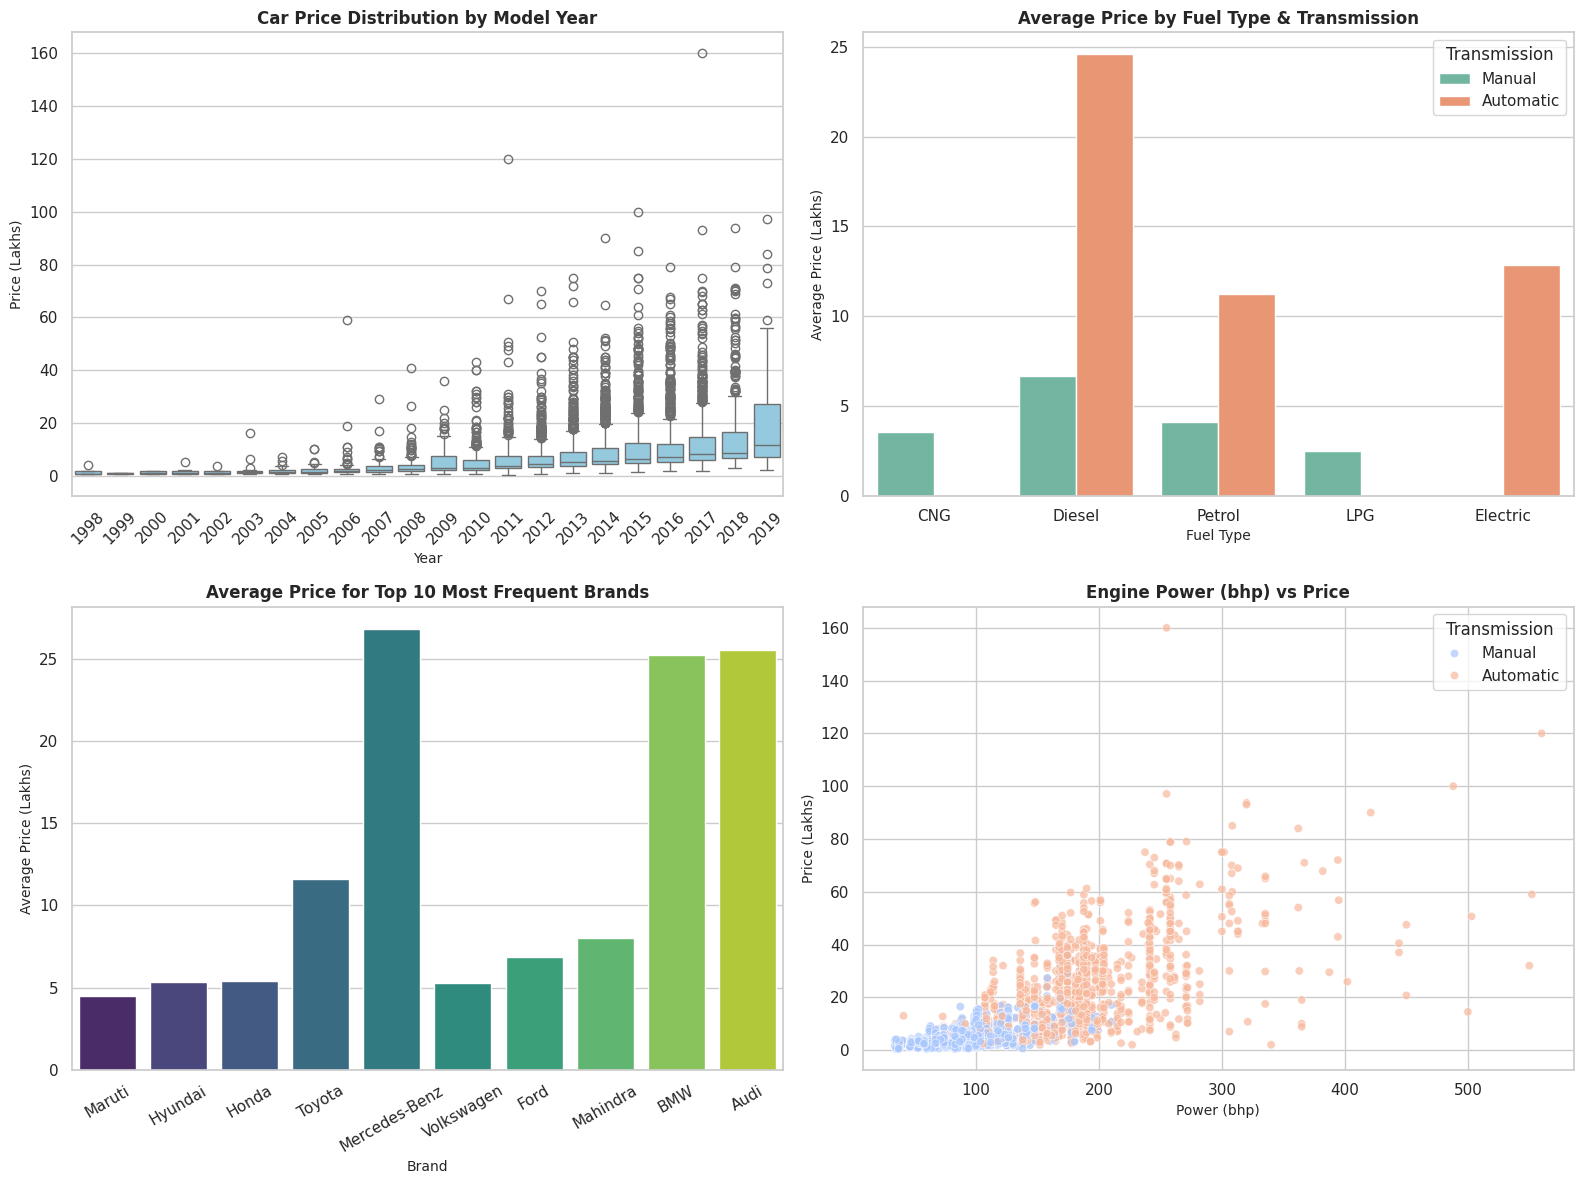

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load dataset
df = pd.read_csv('used_cars_data.csv')

# 2. Data Cleaning Functions for String Numerical Columns
def extract_numeric(value):
    if pd.isna(value) or value in ['null bhp', 'null']:
        return np.nan
    val_str = str(value).split()[0]
    try:
        return float(val_str)
    except ValueError:
        return np.nan

# Clean unit columns
df['Mileage_num'] = df['Mileage'].apply(extract_numeric)
df['Engine_num'] = df['Engine'].apply(extract_numeric)
df['Power_num'] = df['Power'].apply(extract_numeric)

# Extract Brand from Name
df['Brand'] = df['Name'].apply(lambda x: str(x).split()[0])

# Filter rows where Price is present
df_clean = df.dropna(subset=['Price']).copy()

# 3. Create Visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Price Distribution by Model Year
sns.boxplot(data=df_clean, x='Year', y='Price', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Car Price Distribution by Model Year', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year', fontsize=10)
axes[0, 0].set_ylabel('Price (Lakhs)', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Average Price by Fuel Type & Transmission
sns.barplot(data=df_clean, x='Fuel_Type', y='Price', hue='Transmission', ax=axes[0, 1], palette='Set2', errorbar=None)
axes[0, 1].set_title('Average Price by Fuel Type & Transmission', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Fuel Type', fontsize=10)
axes[0, 1].set_ylabel('Average Price (Lakhs)', fontsize=10)

# Chart 3: Average Price across Top 10 Car Brands
top_10_brands = df_clean['Brand'].value_counts().head(10).index
df_top_brands = df_clean[df_clean['Brand'].isin(top_10_brands)]
sns.barplot(data=df_top_brands, x='Brand', y='Price', ax=axes[1, 0], palette='viridis', order=top_10_brands, errorbar=None)
axes[1, 0].set_title('Average Price for Top 10 Most Frequent Brands', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Brand', fontsize=10)
axes[1, 0].set_ylabel('Average Price (Lakhs)', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=30)

# Chart 4: Engine Power (bhp) vs Price
sns.scatterplot(data=df_clean, x='Power_num', y='Price', hue='Transmission', alpha=0.7, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Engine Power (bhp) vs Price', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Power (bhp)', fontsize=10)
axes[1, 1].set_ylabel('Price (Lakhs)', fontsize=10)

plt.tight_layout()
plt.show()

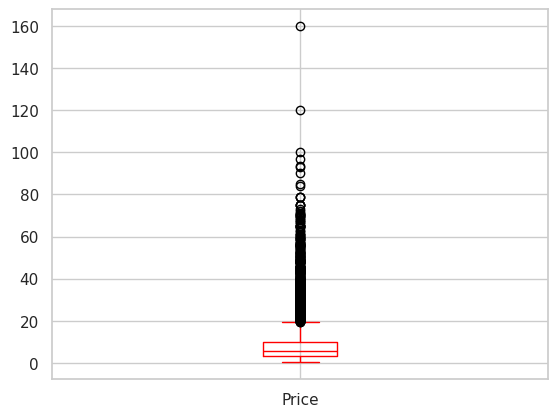

In [ ]:
df["Price"].plot(kind="box", color="red")
#df.boxplot(column="Price", by="Location")
plt.show()

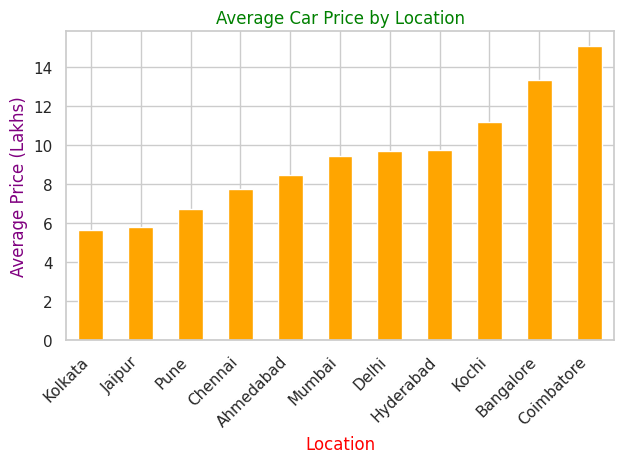

In [ ]:
ax = sales.plot(kind="bar", color="orange")

ax.set_xlabel("Location", color="red")
ax.set_ylabel("Average Price (Lakhs)", color="purple")
ax.set_title("Average Car Price by Location", color="green")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

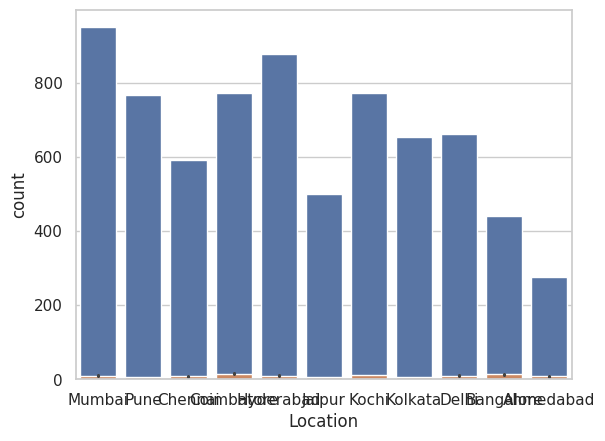

In [ ]:
import seaborn as sns
sns.countplot(data=df, x="Location")
sns.barplot(data=df,x="Location", y="Price")
plt.show()

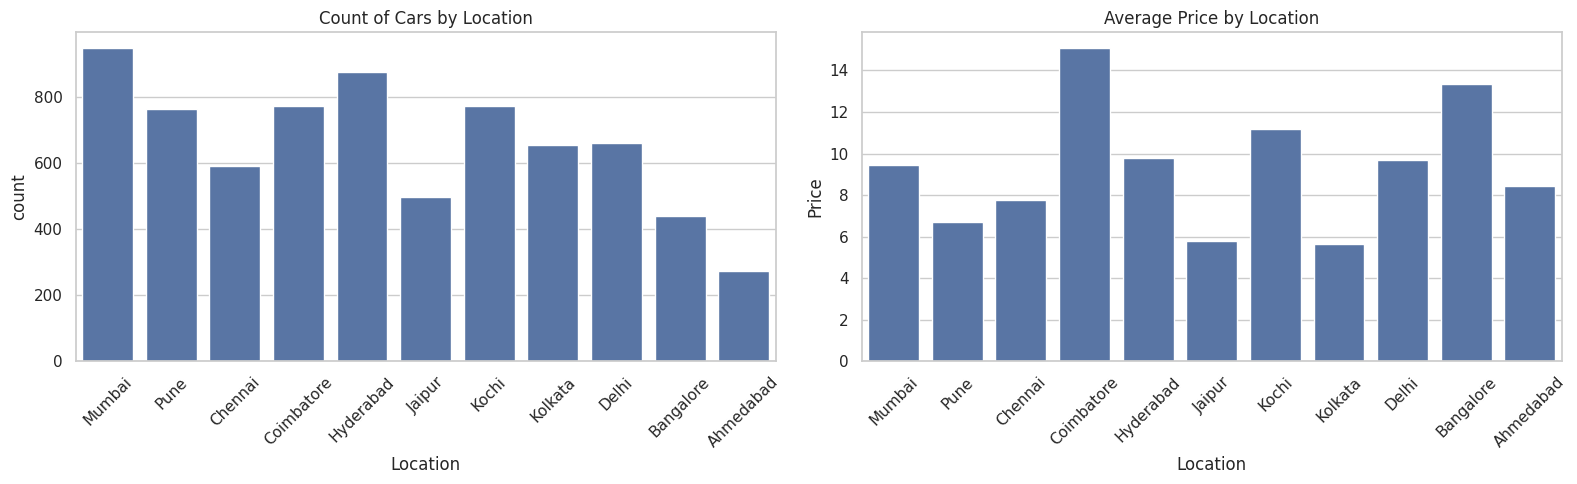

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("used_cars_data.csv")

# Create subplots for two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Count of cars per location
sns.countplot(data=df, x="Location", ax=axes[0])
axes[0].set_title("Count of Cars by Location")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Average price per location
sns.barplot(data=df, x="Location", y="Price", ax=axes[1], errorbar=None)
axes[1].set_title("Average Price by Location")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.savefig("charts.png", dpi=150, bbox_inches="tight")
plt.show()


<Axes: xlabel='Year', ylabel='Price'>

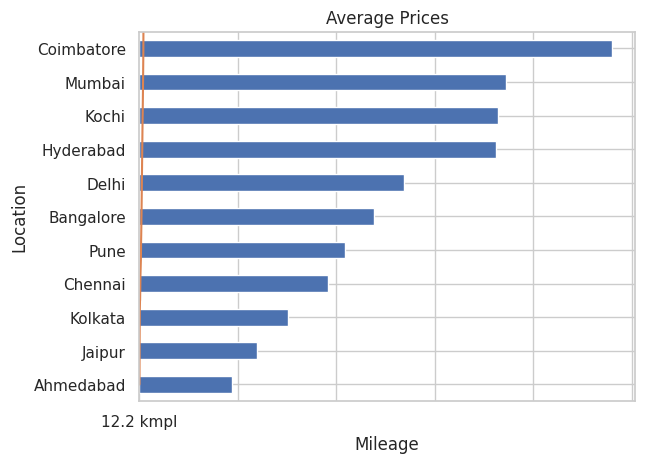

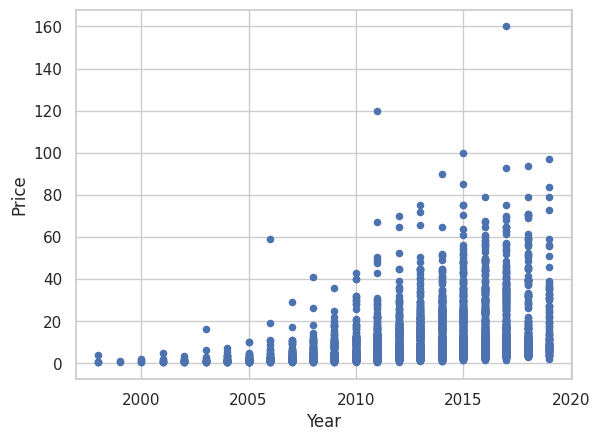

In [ ]:
df["Price"].plot(kind="hist", bins=30, title="Average Prices")
df.groupby("Location")["Price"].sum().sort_values().plot(kind="barh")
df.groupby("Mileage")["Price"].sum().sort_values().plot(kind="line")
df.plot(kind="scatter", x="Year", y="Price")


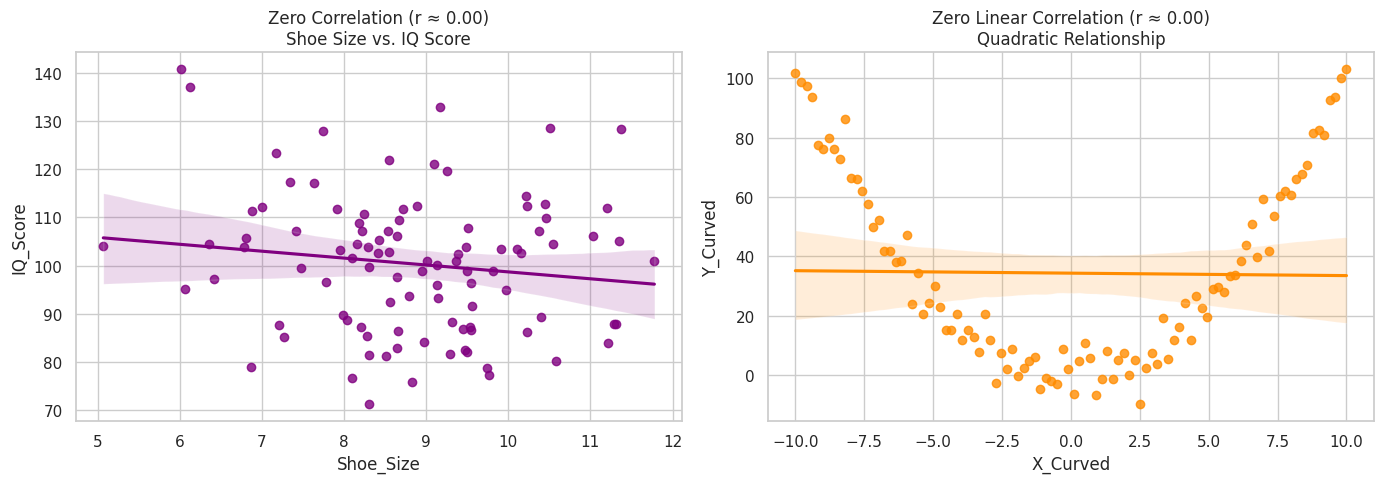

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 100

# 1. Completely Independent Data
shoe_size = np.random.normal(9, 1.5, n)
iq_score = np.random.normal(100, 15, n)

# 2. Non-Linear (Quadratic) Data
x_curved = np.linspace(-10, 10, n)
y_curved = x_curved**2 + np.random.normal(0, 5, n)

df_zero = pd.DataFrame({
    'Shoe_Size': shoe_size,
    'IQ_Score': iq_score,
    'X_Curved': x_curved,
    'Y_Curved': y_curved
})

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Independent variables
sns.regplot(data=df_zero, x='Shoe_Size', y='IQ_Score', ax=axes[0], color='purple')
axes[0].set_title('Zero Correlation (r ≈ 0.00)\nShoe Size vs. IQ Score')

# Plot 2: Curved (Non-linear) relationship
sns.regplot(data=df_zero, x='X_Curved', y='Y_Curved', ax=axes[1], color='darkorange')
axes[1].set_title('Zero Linear Correlation (r ≈ 0.00)\nQuadratic Relationship')

plt.tight_layout()
plt.savefig('zero_correlation_examples.png', dpi=150, bbox_inches='tight')
plt.show()